In [12]:
import json

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.metrics import classification_report, confusion_matrix, f1_score


import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import v2
import torch.nn as nn

import time
from pathlib import Path

In [3]:
path_to_labels = 'cassava-leaf-disease-classification/train.csv'

df = pd.read_csv(path_to_labels) # Read the labels

# Forming 80/10/10 train, validate, test splits

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# Ensuring batches are disjoint from one another and that all batches add up to 100%

assert len(train_df) + len(val_df) + len(test_df) == len(df)

assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)

class CassavaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, return_path=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = os.path.join(self.image_dir, row["image_id"])

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        if self.return_path:
            return image, label, image_path

        return image, label

# Setting up transformation initial test

train_transform = v2.Compose([
    v2.RandomResizedCrop(224, scale=(0.8, 1.0)), # Cropping random portion of the input and resizing it. Scale gives lower and upper bound for the crop area
    v2.RandomHorizontalFlip(), # 50% probability that an image is horizontally flipped
    v2.RandomRotation(degrees=15), # Rotates every image by a random degree from [-15, +15]
    v2.ColorJitter( # Randomly changes the brightnes, contrast, saturation of an image
        brightness=0.1, # Brightness factor is jittered uniformly between [max(0, 1-[0.1]), 1 + [0.1]]
        contrast=0.1, # Contrast factor is jittered uniformly between [max(0, 1-[0.1], (1 + [0.1])]
        saturation=0.1, # Saturation factor is jittered uniformly between [max(0, 1-[0.1]), (1+ [0.1])]
    ),
    v2.ToImage(), # Make image a tensor
    v2.ToDtype(torch.float32, scale=True), # Converts image to have datatype float32. We use float32 rather than uint8 since the network needs floating point numbers to correctly operate. Scale move the image from [0, 225] (default uint8 for JPEG) -> [0, 1]
    v2.Normalize(
        mean=[0.485, 0.456, 0.406], # Mean & Std come directly from the ResNet-18 default models
        std=[0.229, 0.224, 0.225]
    )
])

# Setting up validation transformation

val_transform = v2.Compose([
    v2.Resize(256), # Rescaling to (256 * height/width, 256)
    v2.CenterCrop(224), # Crops the image to size (224x224)
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [2]:
def warm_image_cache(directory):
    directory = Path(directory)
    files = list(directory.rglob("*"))
    files = [p for p in files if p.is_file()]

    total_bytes = sum(p.stat().st_size for p in files)

    print(
        f"Warming cache for {len(files):,} files "
        f"({total_bytes / 1024**3:.2f} GiB)..."
    )

    start = time.perf_counter()

    for i, path in enumerate(files, 1):
        with open(path, "rb") as f:
            while f.read(1024 * 1024):
                pass

        if i % 2000 == 0:
            print(f"{i:,}/{len(files):,} files")

    elapsed = time.perf_counter() - start
    print(f"Cache warm-up completed in {elapsed:.1f}s")

image_dir = 'cassava-leaf-disease-classification/train_images'

warm_image_cache(image_dir)

Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 0.6s


In [ ]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

In [4]:
# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

def training_loop(dataloader, model, loss_fn, optimizer, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.train()

    total_loss = torch.zeros((), device=device)
    num_correct = torch.zeros((), device=device)
    num_seen = 0

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.detach() * y.size(0)
        num_correct += (pred.argmax(dim=1) == y).sum()
        num_seen += y.size(0)

        if batch % 100 == 0:
            loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
            print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = (num_correct / num_seen).item()
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = (total_loss / num_seen).item()
        loss_tracker.append(avg_loss)

def validation_loop(dataloader, model, loss_fn, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.eval()

    total_loss = torch.zeros((), device=device)
    num_correct = torch.zeros((), device=device)
    num_seen = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(X)
            loss = loss_fn(pred, y)

            total_loss += loss.detach() * y.size(0)
            num_correct += (pred.argmax(dim=1) == y).sum()
            num_seen += y.size(0)

            if batch % 100 == 0:
                loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
                print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = (num_correct / num_seen).item()
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = (total_loss/num_seen).item()
        loss_tracker.append(avg_loss)

# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers = 4, persistent_workers=True, prefetch_factor = 4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers = 4, persistent_workers=True, prefetch_factor = 4)

In [ ]:
lr = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

In [ ]:
epochs = 15
best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0
min_delta = 1e-4

train_loss = []
train_acc = []

val_loss = []
val_acc = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

    if val_loss[-1] < best_val_loss - min_delta:
        best_val_loss = val_loss[-1]
        epochs_without_improvement = 0
        torch.save({"Epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]}, "best_frozen_resnet18.pt")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

print("Done!")

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title(f"Average Loss for Training and Validation Loss for {epoch} epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title(f"Accuracy for Training and Validation Loss for {epoch} epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [5]:
checkpoint = torch.load("best_frozen_resnet18.pt", weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True # Unfreezing layer 4

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

NameError: name 'model' is not defined

In [ ]:
epochs = 15
best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0
min_delta = 1e-4

train_loss = []
train_acc = []

val_loss = []
val_acc = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

    if val_loss[-1] < best_val_loss - min_delta:
        best_val_loss = val_loss[-1]
        epochs_without_improvement = 0
        torch.save({"Epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]}, "best_finetuned_resnet18.pt")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

print("Done!")

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title(f"Average Loss for Training and Validation Loss for {epoch} epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title(f"Accuracy for Training and Validation Loss for {epoch} epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
checkpoint = torch.load("best_finetuned_resnet18.pt", weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

all_labels = []
all_preds = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)

        preds = logits.argmax(dim=1)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [ ]:
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(macro_f1)

As a quick reminder, we're measuring a few different things in the following cell. Unlike the previous cell where we measure the macro F1 score across all classes, we're going into a class-by-class break down.

Precision is measuring how positive predictions made by the model are correct. Recall is measuring how many positive cases were correctly identified. As mentioned before, the F1 score then tracks the balance between precision and recall with no biases towards either metrics. The classification report also gives us the support for each class. The support is the number of true samples belong to that class.

We are also given the macro average and the weighted averaged. Weighted average gives larger classes more influence where as the macro average treats each class equally.

In [ ]:
path_to_classes = 'cassava-leaf-disease-classification/label_num_to_disease_map.json'

with open(path_to_classes, 'r') as f:
    data = json.load(f)

class_names = list(data.values())

for i in range(len(class_names)):
    name = class_names[i]
    class_names[i] = name.split("(")[-1].split(")")[0]

report = classification_report(all_labels, all_preds, target_names=class_names, digits=3)

print(report)

The columns of the confusion matrix represent the predicted values of the model of a given class, where as the rows represent the actual values of a predicted class. Let's focus on the normalized results, since the un-normalized confusion matrix gives raw numbers which aren't particularly useful at a glance. For example, the first row represents the recall of the CBB class. If the training image is CBB, the recall is about 51%, with most of the mistakes going to the healthy class with about 25% recall. In short, looking at the row normalized matrix will give us the recall of each class along with the recall of where the actual class is being misclassified.

Looking column-wise is a bit more confusing given the normalized results since the matrix is normalized row-wise so column wise comparisons are based on different scales. Instead of the row normalized matrix, we use the column normalized matrix. Here, the column-wise interpretation is say given everything predicted as that class, xx% was that class. For example, given all the labels the model predicted to be CBB, 55% of the predictions were CBB. In summary, the column-wise normalized matrix will give us the precision of the model.

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_row_normalized = confusion_matrix(all_labels, all_preds, normalize='true')
cm_column_normalized = confusion_matrix(all_labels, all_preds, normalize='pred')

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].matshow(cm, cmap='viridis')
ax[0].set_title('Confusion Matrix')
ax[0].axis('off')

im1 = ax[1].matshow(cm_row_normalized, cmap='viridis')
ax[1].set_title('Row Normalized Confusion Matrix')
ax[1].axis('off')
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax, ax=ax[1])

im2 = ax[2].matshow(cm_column_normalized, cmap='viridis')
ax[2].set_title('Column Normalized Confusion Matrix')
ax[2].axis('off')
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, cax=cax, ax=ax[2])

plt.tight_layout()
plt.show()

print(f'Confusion Matrix:\n{cm}\n\nRow Normalized Confusion Matrix:\n{cm_row_normalized}\n\nColumn Normalized Confusion Matrix:\n{cm_column_normalized}')

In [7]:
from sklearn.utils.class_weight import compute_class_weight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

classes = np.sort(train_df["label"].unique())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df["label"])

class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

Using device: cuda


In [8]:
checkpoint = torch.load('best_finetuned_resnet18.pt', weights_only=False)

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)
model.load_state_dict(checkpoint['model_state_dict'])

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True # Unfreezing layer 4

for param in model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cuda


In [10]:
epochs = 15
best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0
min_delta = 1e-4

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

train_loss = []
train_acc = []

val_loss = []
val_acc = []

warm_image_cache(image_dir)

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

    if val_loss[-1] < best_val_loss - min_delta:
        best_val_loss = val_loss[-1]
        epochs_without_improvement = 0
        torch.save({"Epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]}, "best_weighted_resnet18.pt")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

print("Done!")

Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 0.8s
Epoch 1...
BATCH 0 -> loss 0.697416  [32.000000/17117]
BATCH 100 -> loss 1.377403  [3232.000000/17117]
BATCH 200 -> loss 0.689591  [6432.000000/17117]
BATCH 300 -> loss 0.670230  [9632.000000/17117]
BATCH 400 -> loss 0.643680  [12832.000000/17117]
BATCH 500 -> loss 0.932856  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.538836  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 0.643105  [32.000000/17117]
BATCH 100 -> loss 0.738862  [3232.000000/17117]
BATCH 200 -> loss 0.863931  [6432.000000/17117]
BATCH 300 -> loss 0.620399  [9632.000000/17117]
BATCH 400 -> loss 0.587765  [12832.000000/17117]
BATCH 500 -> loss 1.030412  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.642649  [32.000000/ 2140]
Epoch 3...
BATCH 

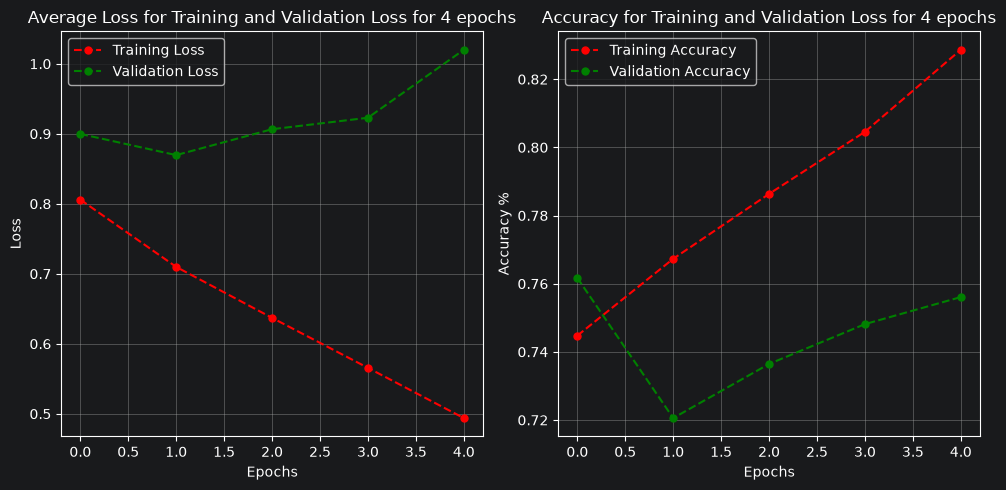

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title(f"Average Loss for Training and Validation Loss for {epoch + 1} epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title(f"Accuracy for Training and Validation Loss for {epoch + 1} epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [16]:
checkpoint = torch.load("best_weighted_resnet18.pt", weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)

        preds = logits.argmax(dim=1)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

weighted_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

path_to_classes = 'cassava-leaf-disease-classification/label_num_to_disease_map.json'

with open(path_to_classes, 'r') as f:
    data = json.load(f)

class_names = list(data.values())

for i in range(len(class_names)):
    name = class_names[i]
    class_names[i] = name.split("(")[-1].split(")")[0]

report = classification_report(all_labels, all_preds, target_names=class_names, digits=3)
print(f"Macro F1: {macro_f1}\nWeighted F1: {weighted_f1}\nReport:\n{report}")

Macro F1: 0.5889160348650038
Weighted F1: 0.7406004264177134
Report:
              precision    recall  f1-score   support

         CBB      0.308     0.417     0.354       108
        CBSD      0.522     0.658     0.582       219
         CGM      0.497     0.686     0.576       239
         CMD      0.973     0.774     0.862      1316
     Healthy      0.500     0.663     0.570       258

    accuracy                          0.721      2140
   macro avg      0.560     0.639     0.589      2140
weighted avg      0.783     0.721     0.741      2140



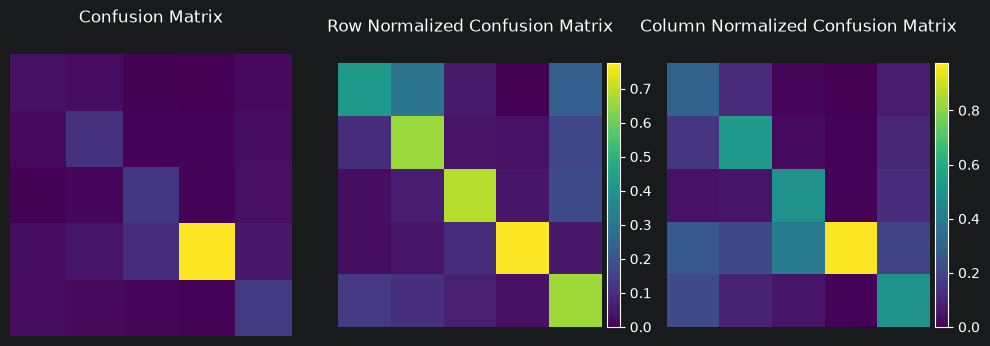

Confusion Matrix:
[[  45   32    6    0   25]
 [  22  144    9    8   36]
 [   7   15  164   11   42]
 [  39   58  133 1018   68]
 [  33   27   18    9  171]]

Row Normalized Confusion Matrix:
[[0.41666667 0.2962963  0.05555556 0.         0.23148148]
 [0.10045662 0.65753425 0.04109589 0.03652968 0.16438356]
 [0.0292887  0.06276151 0.68619247 0.0460251  0.17573222]
 [0.02963526 0.04407295 0.10106383 0.77355623 0.05167173]
 [0.12790698 0.10465116 0.06976744 0.03488372 0.6627907 ]]

Column Normalized Confusion Matrix:
[[0.30821918 0.11594203 0.01818182 0.         0.07309942]
 [0.15068493 0.52173913 0.02727273 0.00764818 0.10526316]
 [0.04794521 0.05434783 0.4969697  0.01051625 0.12280702]
 [0.26712329 0.21014493 0.4030303  0.97323136 0.19883041]
 [0.2260274  0.09782609 0.05454545 0.00860421 0.5       ]]


In [17]:
cm = confusion_matrix(all_labels, all_preds)
cm_row_normalized = confusion_matrix(all_labels, all_preds, normalize='true')
cm_column_normalized = confusion_matrix(all_labels, all_preds, normalize='pred')

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].matshow(cm, cmap='viridis')
ax[0].set_title('Confusion Matrix')
ax[0].axis('off')

im1 = ax[1].matshow(cm_row_normalized, cmap='viridis')
ax[1].set_title('Row Normalized Confusion Matrix')
ax[1].axis('off')
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax, ax=ax[1])

im2 = ax[2].matshow(cm_column_normalized, cmap='viridis')
ax[2].set_title('Column Normalized Confusion Matrix')
ax[2].axis('off')
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, cax=cax, ax=ax[2])

plt.tight_layout()
plt.show()

print(f'Confusion Matrix:\n{cm}\n\nRow Normalized Confusion Matrix:\n{cm_row_normalized}\n\nColumn Normalized Confusion Matrix:\n{cm_column_normalized}')

In [28]:
class_counts = (train_df["label"].value_counts().sort_index())
counts = torch.tensor(class_counts.values, dtype = torch.float32)

class_weights = 1 /torch.sqrt(counts)

class_weights = class_weights/class_weights.mean()

In [31]:
checkpoint = torch.load('best_finetuned_resnet18.pt', weights_only=False)

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)
model.load_state_dict(checkpoint['model_state_dict'])

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True # Unfreezing layer 4

for param in model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)
class_weights = class_weights.to(device)

Using device: cuda


In [32]:
epochs = 15
best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0
min_delta = 1e-4

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

train_loss = []
train_acc = []

val_loss = []
val_acc = []

warm_image_cache(image_dir)

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

    if val_loss[-1] < best_val_loss - min_delta:
        best_val_loss = val_loss[-1]
        epochs_without_improvement = 0
        torch.save({"Epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]}, "best_sqrt_weighted_resnet18.pt")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

print("Done!")

Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 0.6s
Epoch 1...
BATCH 0 -> loss 0.413281  [32.000000/17117]
BATCH 100 -> loss 0.434140  [3232.000000/17117]
BATCH 200 -> loss 0.862258  [6432.000000/17117]
BATCH 300 -> loss 1.171917  [9632.000000/17117]
BATCH 400 -> loss 0.512413  [12832.000000/17117]
BATCH 500 -> loss 0.718104  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.402881  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 1.066461  [32.000000/17117]
BATCH 100 -> loss 0.690393  [3232.000000/17117]
BATCH 200 -> loss 0.796657  [6432.000000/17117]
BATCH 300 -> loss 0.803436  [9632.000000/17117]
BATCH 400 -> loss 0.677558  [12832.000000/17117]
BATCH 500 -> loss 0.665812  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.448337  [32.000000/ 2140]
Epoch 3...
BATCH 

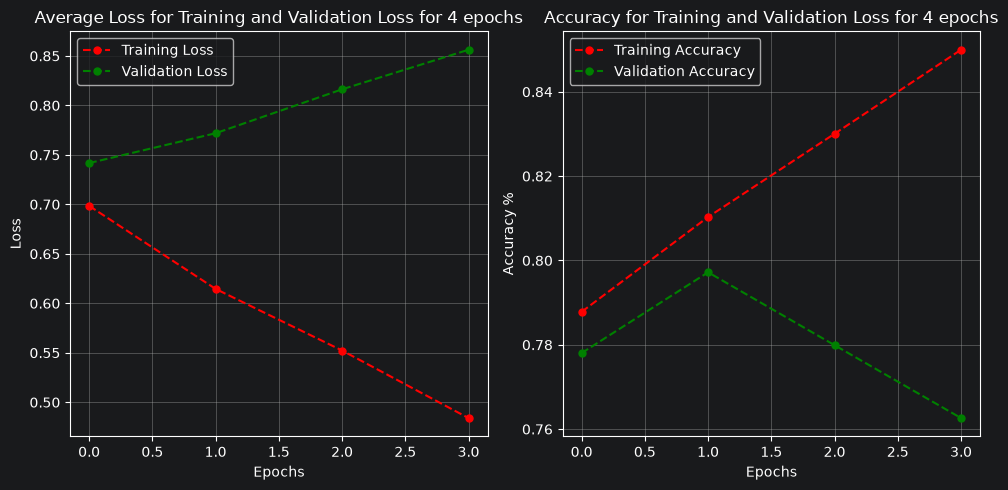

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title(f"Average Loss for Training and Validation Loss for {epoch + 1} epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title(f"Accuracy for Training and Validation Loss for {epoch + 1} epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [34]:
checkpoint = torch.load("best_sqrt_weighted_resnet18.pt", weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)

        preds = logits.argmax(dim=1)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

weighted_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

path_to_classes = 'cassava-leaf-disease-classification/label_num_to_disease_map.json'

with open(path_to_classes, 'r') as f:
    data = json.load(f)

class_names = list(data.values())

for i in range(len(class_names)):
    name = class_names[i]
    class_names[i] = name.split("(")[-1].split(")")[0]

report = classification_report(all_labels, all_preds, target_names=class_names, digits=3)
print(f"Macro F1: {macro_f1}\nWeighted F1: {weighted_f1}\nReport:\n{report}")

Macro F1: 0.6445090205177093
Weighted F1: 0.7867639922227417
Report:
              precision    recall  f1-score   support

         CBB      0.479     0.519     0.498       108
        CBSD      0.740     0.493     0.592       219
         CGM      0.599     0.674     0.634       239
         CMD      0.954     0.869     0.909      1316
     Healthy      0.480     0.764     0.590       258

    accuracy                          0.778      2140
   macro avg      0.650     0.663     0.645      2140
weighted avg      0.811     0.778     0.787      2140



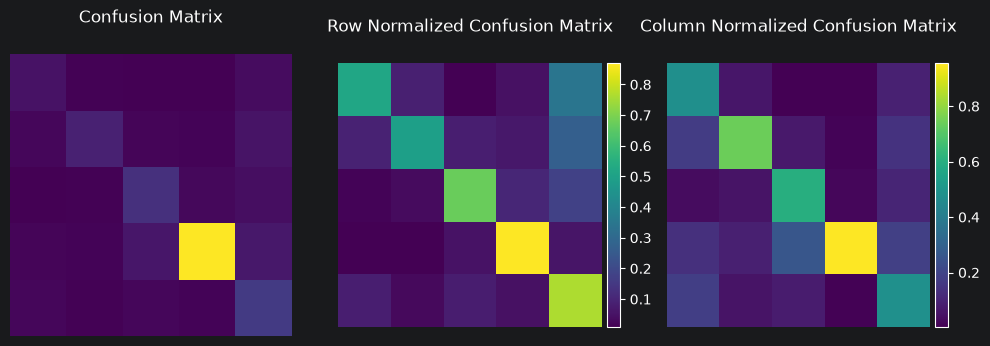

Confusion Matrix:
[[  56    9    1    5   37]
 [  20  108   18   14   59]
 [   4    8  161   24   42]
 [  16   13   69 1143   75]
 [  21    8   20   12  197]]

Row Normalized Confusion Matrix:
[[0.51851852 0.08333333 0.00925926 0.0462963  0.34259259]
 [0.0913242  0.49315068 0.08219178 0.06392694 0.26940639]
 [0.0167364  0.0334728  0.67364017 0.10041841 0.17573222]
 [0.01215805 0.00987842 0.05243161 0.86854103 0.05699088]
 [0.08139535 0.03100775 0.07751938 0.04651163 0.76356589]]

Column Normalized Confusion Matrix:
[[0.47863248 0.06164384 0.00371747 0.00417362 0.0902439 ]
 [0.17094017 0.73972603 0.0669145  0.01168614 0.14390244]
 [0.03418803 0.05479452 0.59851301 0.02003339 0.10243902]
 [0.13675214 0.0890411  0.25650558 0.95409015 0.18292683]
 [0.17948718 0.05479452 0.07434944 0.01001669 0.4804878 ]]


In [35]:
cm = confusion_matrix(all_labels, all_preds)
cm_row_normalized = confusion_matrix(all_labels, all_preds, normalize='true')
cm_column_normalized = confusion_matrix(all_labels, all_preds, normalize='pred')

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].matshow(cm, cmap='viridis')
ax[0].set_title('Confusion Matrix')
ax[0].axis('off')

im1 = ax[1].matshow(cm_row_normalized, cmap='viridis')
ax[1].set_title('Row Normalized Confusion Matrix')
ax[1].axis('off')
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax, ax=ax[1])

im2 = ax[2].matshow(cm_column_normalized, cmap='viridis')
ax[2].set_title('Column Normalized Confusion Matrix')
ax[2].axis('off')
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, cax=cax, ax=ax[2])

plt.tight_layout()
plt.show()

print(f'Confusion Matrix:\n{cm}\n\nRow Normalized Confusion Matrix:\n{cm_row_normalized}\n\nColumn Normalized Confusion Matrix:\n{cm_column_normalized}')

In [36]:
checkpoint = torch.load('best_finetuned_resnet18.pt', weights_only=False)

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)
model.load_state_dict(checkpoint['model_state_dict'])

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True # Unfreezing layer 4

for param in model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cuda


In [37]:
epochs = 15
best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0
min_delta = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

train_loss = []
train_acc = []

val_loss = []
val_acc = []

warm_image_cache(image_dir)

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

    if val_loss[-1] < best_val_loss - min_delta:
        best_val_loss = val_loss[-1]
        epochs_without_improvement = 0
        torch.save({"Epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]}, "best_sqrt_weighted_resnet18.pt")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

print("Done!")

Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 0.6s
Epoch 1...
BATCH 0 -> loss 0.488257  [32.000000/17117]
BATCH 100 -> loss 0.596004  [3232.000000/17117]
BATCH 200 -> loss 0.470798  [6432.000000/17117]
BATCH 300 -> loss 0.525157  [9632.000000/17117]
BATCH 400 -> loss 0.496856  [12832.000000/17117]
BATCH 500 -> loss 0.660061  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.452061  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 0.630528  [32.000000/17117]
BATCH 100 -> loss 0.472550  [3232.000000/17117]
BATCH 200 -> loss 0.349352  [6432.000000/17117]
BATCH 300 -> loss 0.410589  [9632.000000/17117]
BATCH 400 -> loss 0.450673  [12832.000000/17117]
BATCH 500 -> loss 0.527355  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.313487  [32.000000/ 2140]
Epoch 3...
BATCH 

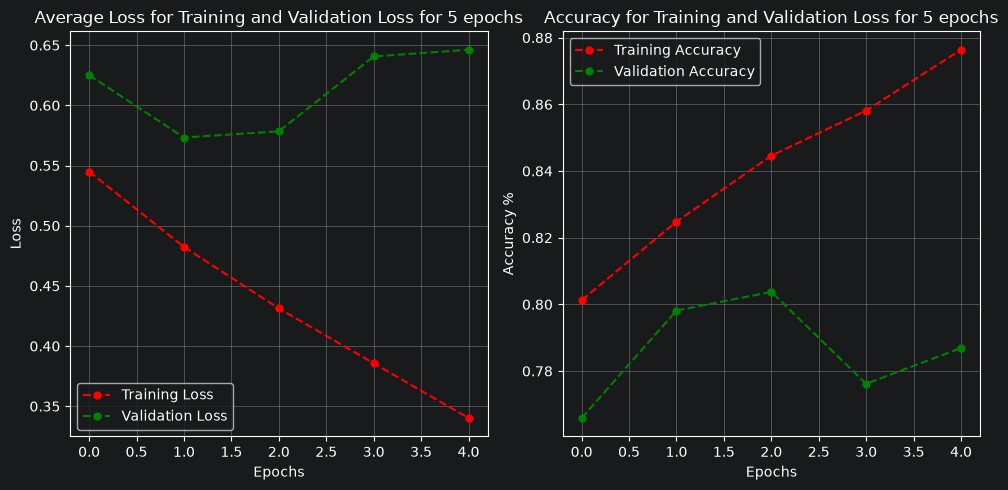

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title(f"Average Loss for Training and Validation Loss for {epoch + 1} epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title(f"Accuracy for Training and Validation Loss for {epoch + 1} epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [39]:
checkpoint = torch.load("best_sqrt_weighted_resnet18.pt", weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)

        preds = logits.argmax(dim=1)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

weighted_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

path_to_classes = 'cassava-leaf-disease-classification/label_num_to_disease_map.json'

with open(path_to_classes, 'r') as f:
    data = json.load(f)

class_names = list(data.values())

for i in range(len(class_names)):
    name = class_names[i]
    class_names[i] = name.split("(")[-1].split(")")[0]

report = classification_report(all_labels, all_preds, target_names=class_names, digits=3)
print(f"Macro F1: {macro_f1}\nWeighted F1: {weighted_f1}\nReport:\n{report}")

Macro F1: 0.644904746054054
Weighted F1: 0.7933365161656456
Report:
              precision    recall  f1-score   support

         CBB      0.528     0.435     0.477       108
        CBSD      0.677     0.507     0.580       219
         CGM      0.701     0.598     0.646       239
         CMD      0.900     0.939     0.919      1316
     Healthy      0.553     0.663     0.603       258

    accuracy                          0.798      2140
   macro avg      0.672     0.628     0.645      2140
weighted avg      0.794     0.798     0.793      2140



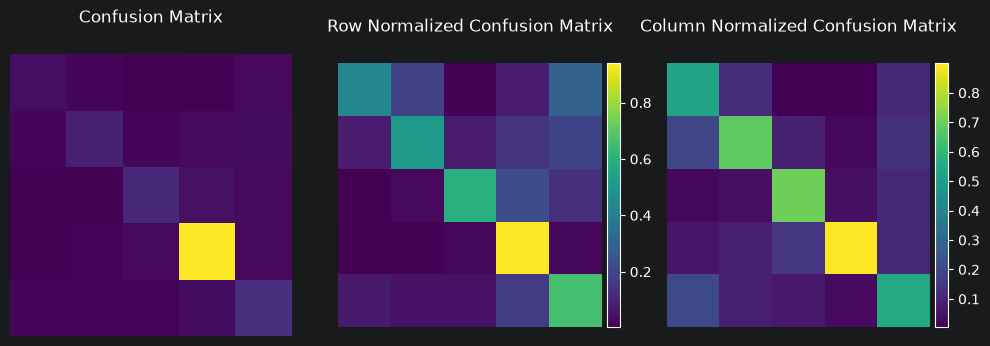

Confusion Matrix:
[[  47   20    1    8   32]
 [  17  111   17   32   42]
 [   2    7  143   55   32]
 [   5   13   30 1236   32]
 [  18   13   13   43  171]]

Row Normalized Confusion Matrix:
[[0.43518519 0.18518519 0.00925926 0.07407407 0.2962963 ]
 [0.07762557 0.50684932 0.07762557 0.14611872 0.19178082]
 [0.0083682  0.0292887  0.59832636 0.23012552 0.13389121]
 [0.00379939 0.00987842 0.02279635 0.93920973 0.02431611]
 [0.06976744 0.0503876  0.0503876  0.16666667 0.6627907 ]]

Column Normalized Confusion Matrix:
[[0.52808989 0.12195122 0.00490196 0.00582242 0.10355987]
 [0.19101124 0.67682927 0.08333333 0.02328967 0.13592233]
 [0.02247191 0.04268293 0.70098039 0.04002911 0.10355987]
 [0.05617978 0.07926829 0.14705882 0.89956332 0.10355987]
 [0.20224719 0.07926829 0.06372549 0.03129549 0.55339806]]


In [40]:
cm = confusion_matrix(all_labels, all_preds)
cm_row_normalized = confusion_matrix(all_labels, all_preds, normalize='true')
cm_column_normalized = confusion_matrix(all_labels, all_preds, normalize='pred')

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

ax[0].matshow(cm, cmap='viridis')
ax[0].set_title('Confusion Matrix')
ax[0].axis('off')

im1 = ax[1].matshow(cm_row_normalized, cmap='viridis')
ax[1].set_title('Row Normalized Confusion Matrix')
ax[1].axis('off')
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax, ax=ax[1])

im2 = ax[2].matshow(cm_column_normalized, cmap='viridis')
ax[2].set_title('Column Normalized Confusion Matrix')
ax[2].axis('off')
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, cax=cax, ax=ax[2])

plt.tight_layout()
plt.show()

print(f'Confusion Matrix:\n{cm}\n\nRow Normalized Confusion Matrix:\n{cm_row_normalized}\n\nColumn Normalized Confusion Matrix:\n{cm_column_normalized}')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

epochs = 15
patience = 3
min_delta = 1e-4

unweighted_val_accuracy = []
unweighted_macro_f1 = []
unweighted_weighted_f1 = []

warm_image_cache(image_dir)

for i in range(3):

    print(f"\nRUN {i + 1}")

    checkpoint = torch.load(
        "best_frozen_resnet18.pt",
        weights_only=False
    )

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 5)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Fine-tune layer4 + fc
    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam([
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-3
        },
    ])

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    checkpoint_path = f"unweighted_run_{i + 1}.pt"

    for epoch in range(epochs):

        print(f"Epoch {epoch + 1}...")

        training_loop(
            train_loader,
            model,
            criterion,
            optimizer,
            loss_tracker=train_loss,
            accuracy_tracker=train_acc
        )

        print("Validating...")

        validation_loop(
            val_loader,
            model,
            criterion,
            loss_tracker=val_loss,
            accuracy_tracker=val_acc
        )

        if val_loss[-1] < best_val_loss - min_delta:

            best_val_loss = val_loss[-1]
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]
                },
                checkpoint_path
            )

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping")
            break

    best_checkpoint = torch.load(
        checkpoint_path,
        weights_only=False
    )

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(X)
            preds = logits.argmax(dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    unweighted_val_accuracy.append(
        best_checkpoint["val_accuracy"]
    )

    unweighted_macro_f1.append(
        macro_f1
    )

    unweighted_weighted_f1.append(
        weighted_f1
    )

print("\nDone!")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

epochs = 15
patience = 3
min_delta = 1e-4

unweighted_val_accuracy = []
unweighted_macro_f1 = []
unweighted_weighted_f1 = []

warm_image_cache(image_dir)

for i in range(3):

    print(f"\nRUN {i + 1}")

    checkpoint = torch.load(
        "best_frozen_resnet18.pt",
        weights_only=False
    )

    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 5)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Fine-tune layer4 + fc
    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam([
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),
            "lr": 1e-3
        },
    ])

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    checkpoint_path = f"unweighted_run_{i + 1}.pt"

    for epoch in range(epochs):

        print(f"Epoch {epoch + 1}...")

        training_loop(
            train_loader,
            model,
            criterion,
            optimizer,
            loss_tracker=train_loss,
            accuracy_tracker=train_acc
        )

        print("Validating...")

        validation_loop(
            val_loader,
            model,
            criterion,
            loss_tracker=val_loss,
            accuracy_tracker=val_acc
        )

        if val_loss[-1] < best_val_loss - min_delta:

            best_val_loss = val_loss[-1]
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]
                },
                checkpoint_path
            )

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping")
            break

    best_checkpoint = torch.load(
        checkpoint_path,
        weights_only=False
    )

    model.load_state_dict(
        best_checkpoint["model_state_dict"]
    )

    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(X)
            preds = logits.argmax(dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    unweighted_val_accuracy.append(
        best_checkpoint["val_accuracy"]
    )

    unweighted_macro_f1.append(
        macro_f1
    )

    unweighted_weighted_f1.append(
        weighted_f1
    )

print("\nDone!")